In [24]:
pip install shap

   ---------------------------------------- 0.0/41.9 MB ? eta -:--:--
   ----- ---------------------------------- 5.2/41.9 MB 26.5 MB/s eta 0:00:02
   ---------- ----------------------------- 11.3/41.9 MB 26.1 MB/s eta 0:00:02
   --------------- ------------------------ 16.3/41.9 MB 24.9 MB/s eta 0:00:02
   --------------------- ------------------ 22.5/41.9 MB 26.4 MB/s eta 0:00:01
   -------------------------- ------------- 28.0/41.9 MB 26.5 MB/s eta 0:00:01
   ---------------------------------- ----- 35.9/41.9 MB 28.2 MB/s eta 0:00:01
   ---------------------------------------  41.7/41.9 MB 27.9 MB/s eta 0:00:01
   ---------------------------------------- 41.9/41.9 MB 25.4 MB/s  0:00:01
   ---------------------------------------- 0.0/2.8 MB ? eta -:--:--
   ---------------------------------------- 2.8/2.8 MB 27.2 MB/s  0:00:00

   ---------------------------------------- 0/5 [slicer]
   -------- ------------------------------- 1/5 [llvmlite]
   -------- ------------------------------


[notice] A new release of pip is available: 26.1.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [1]:
import numpy as np # linear algebra
import pandas as pd

df= pd.read_csv("datos/train.csv")
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 668665 entries, 0 to 668664
Data columns (total 15 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   id                           668665 non-null  int64  
 1   Age                          668665 non-null  int64  
 2   Annual_Income_USD            668665 non-null  float64
 3   Daily_Commute_km             668665 non-null  float64
 4   Number_of_Cars_Owned         668665 non-null  int64  
 5   Charging_Stations_Near_Home  668665 non-null  int64  
 6   Charging_Stations_Near_Work  668665 non-null  int64  
 7   Environmental_Concern_Level  668665 non-null  float64
 8   Gender                       668665 non-null  str    
 9   City_Type                    668665 non-null  str    
 10  Current_Car_Type             668665 non-null  str    
 11  Home_Charging_Possible       668665 non-null  str    
 12  Subsidy_Available            668665 non-null  str    
 13  Range_Anxi

In [12]:
num = X.select_dtypes(include='number').columns.tolist()
cat = X.select_dtypes(exclude='number').columns.tolist()
print("==============Categoricas==========================")
print(cat)
print("===============Numericas=========================")
print(num)

==============Categoricas==========================
['Gender', 'City_Type', 'Current_Car_Type', 'Home_Charging_Possible', 'Subsidy_Available', 'Range_Anxiety_Level']
===============Numericas=========================
['Age', 'Annual_Income_USD', 'Daily_Commute_km', 'Number_of_Cars_Owned', 'Charging_Stations_Near_Home', 'Charging_Stations_Near_Work', 'Environmental_Concern_Level']


In [11]:
cat=['Gender', 'City_Type', 'Current_Car_Type', 'Home_Charging_Possible',
       'Subsidy_Available', 'Range_Anxiety_Level']
num=['Age', 'Annual_Income_USD', 'Daily_Commute_km',
       'Number_of_Cars_Owned', 'Charging_Stations_Near_Home',
       'Charging_Stations_Near_Work', 'Environmental_Concern_Level']

In [25]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, FunctionTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix
import shap

from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

from sklearn.metrics import (
    roc_auc_score,
    roc_curve,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    precision_recall_curve,
    classification_report
)
from sklearn.compose import ColumnTransformer

from sklearn.svm import LinearSVC


C:\Users\USUARIO\AppData\Local\Programs\Python\Python312\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [14]:
X = df.drop(columns=['id', 'Will_Buy_EV'])
for c in cat:
    X[c] = X[c].astype('category')
y = df['Will_Buy_EV'].map({'No': 0, 'Yes': 1})

X_train, X_val, y_train, y_val = train_test_split(
    X, y, train_size=0.8, random_state=42, stratify=y)

In [15]:
preprocessor = ColumnTransformer(transformers=[
    ("num", StandardScaler(), num),
    ("cat", OneHotEncoder(handle_unknown="ignore"), cat),
])

In [16]:
model = Pipeline(steps=[
    ("prep", preprocessor),
    ("svm", LinearSVC(C=1.0, class_weight="balanced", random_state=42))
])
model.fit(X_train, y_train)

y_pred = model.predict(X_val)
y_score = model.decision_function(X_val)   # sirve para AUC

print(classification_report(y_val, y_pred))
print("ROC-AUC:", roc_auc_score(y_val, y_score))

              precision    recall  f1-score   support

           0       0.98      0.84      0.91    110377
           1       0.55      0.90      0.68     23356

    accuracy                           0.85    133733
   macro avg       0.76      0.87      0.79    133733
weighted avg       0.90      0.85      0.87    133733

ROC-AUC: 0.9378580066735207


In [19]:

scores = model.decision_function(X_val)

precision, recall, thresholds = precision_recall_curve(y_val, scores)
f1 = 2 * precision * recall / (precision + recall + 1e-9)

best_idx = np.argmax(f1[:-1])
best_thr = thresholds[best_idx]

print(f"Mejor umbral: {best_thr:.3f}")
print(f"F1 clase 1: {f1[best_idx]:.4f}  (antes: {f1_score(y_val, scores >= 0):.4f})")
print(f"Precision: {precision[best_idx]:.3f} | Recall: {recall[best_idx]:.3f}")

Mejor umbral: 0.305
F1 clase 1: 0.7044  (antes: 0.6830)
Precision: 0.629 | Recall: 0.801


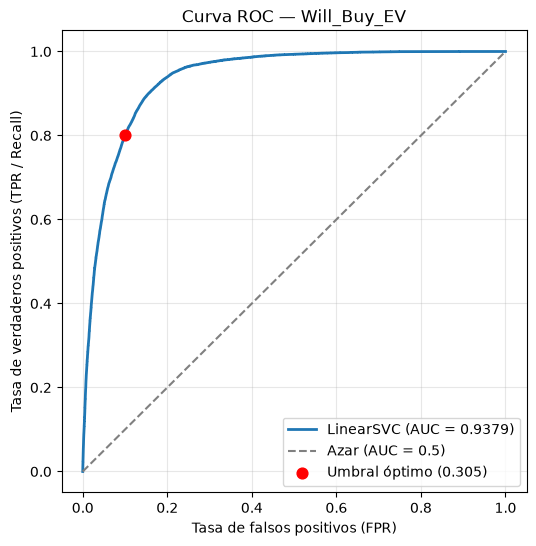

In [20]:
scores = model.decision_function(X_val)
fpr, tpr, thr = roc_curve(y_val, scores)
auc = roc_auc_score(y_val, scores)

# Punto de la curva que corresponde a tu umbral óptimo
idx = np.argmin(np.abs(thr - best_thr))

plt.figure(figsize=(6, 6))
plt.plot(fpr, tpr, lw=2, label=f"LinearSVC (AUC = {auc:.4f})")
plt.plot([0, 1], [0, 1], "--", color="gray", label="Azar (AUC = 0.5)")
plt.scatter(fpr[idx], tpr[idx], color="red", s=60, zorder=3,
            label=f"Umbral óptimo ({best_thr:.3f})")
plt.xlabel("Tasa de falsos positivos (FPR)")
plt.ylabel("Tasa de verdaderos positivos (TPR / Recall)")
plt.title("Curva ROC — Will_Buy_EV")
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.show()

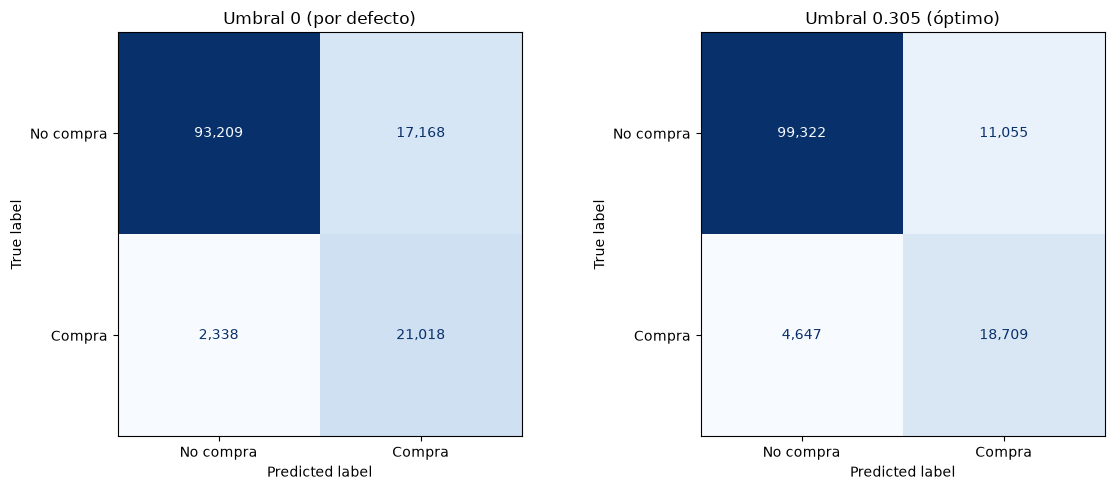

In [21]:
pred_default = (scores >= 0).astype(int)
pred_best    = (scores >= best_thr).astype(int)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, pred, titulo in zip(axes,
                            [pred_default, pred_best],
                            ["Umbral 0 (por defecto)", f"Umbral {best_thr:.3f} (óptimo)"]):
    cm = confusion_matrix(y_val, pred)
    ConfusionMatrixDisplay(cm, display_labels=["No compra", "Compra"]).plot(
        ax=ax, cmap="Blues", values_format=",d", colorbar=False)
    ax.set_title(titulo)

plt.tight_layout()
plt.show()

Background dataset has 1000 samples but max_samples=100. Subsampling to 100 samples for SHAP value computation. To use all samples, set max_samples=1000 when initializing the masker.


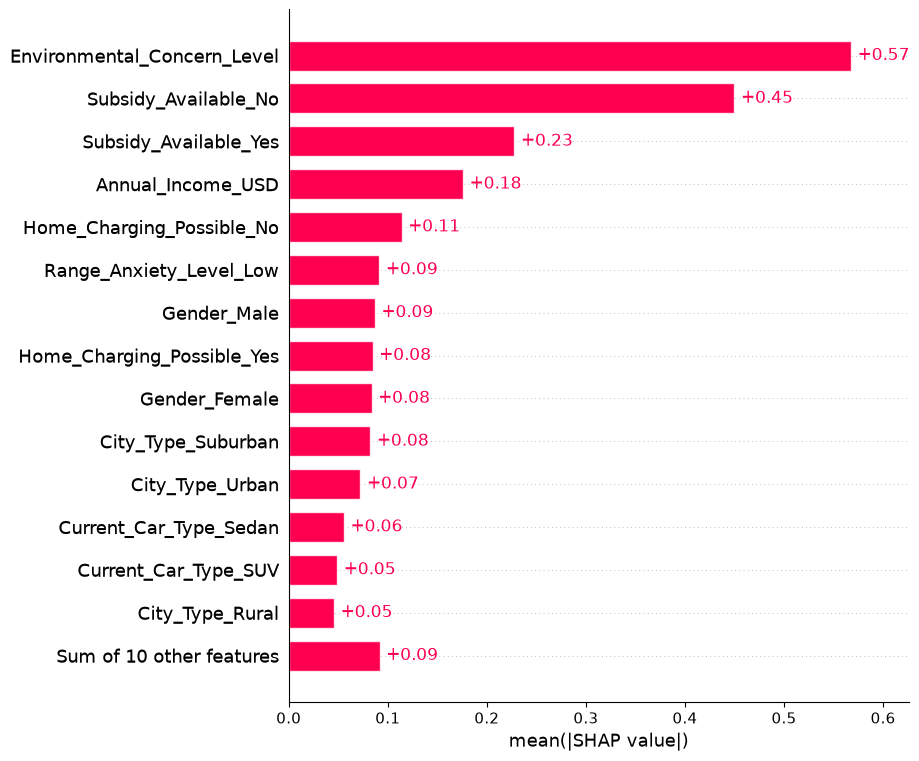

In [31]:
prep = model.named_steps["prep"]
svm  = model.named_steps["svm"]

# Nombres de columnas sin los prefijos "num__" y "cat__"
feature_names = [f.split("__", 1)[1] for f in prep.get_feature_names_out()]

def transformar(X):
    Xt = prep.transform(X)
    if hasattr(Xt, "toarray"):   # por si OneHotEncoder devuelve matriz dispersa
        Xt = Xt.toarray()
    return pd.DataFrame(Xt, columns=feature_names)

# Muestras para que sea rápido
background = transformar(X_train.sample(1000, random_state=42))
X_explain  = transformar(X_val.sample(5000, random_state=42))

explainer   = shap.LinearExplainer((svm.coef_, svm.intercept_), background)
shap_values = explainer(X_explain)
shap.plots.bar(shap_values, max_display=15)


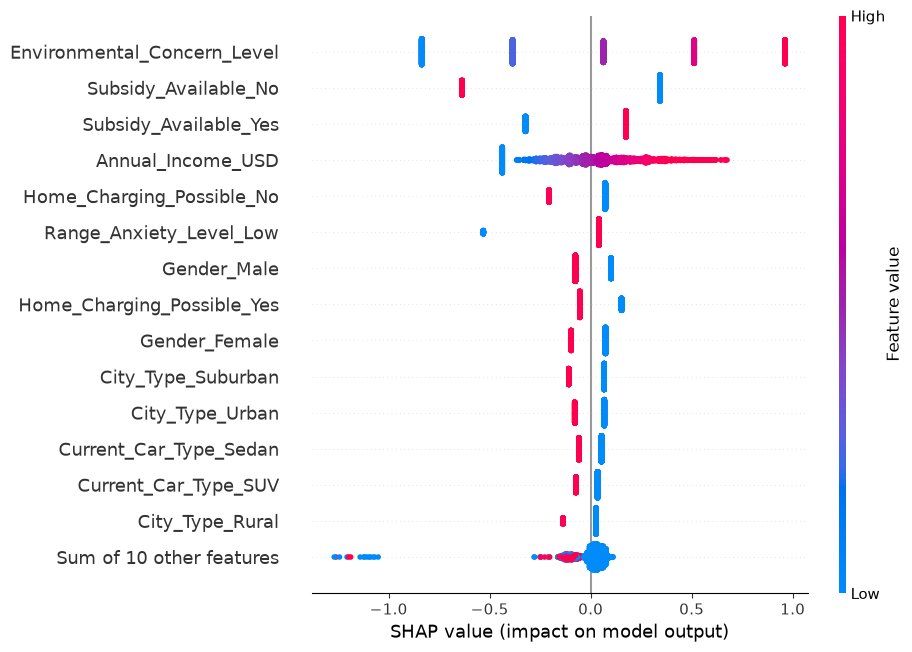

In [32]:
shap.plots.beeswarm(shap_values, max_display=15)

In [34]:
import joblib
import sklearn

artefacto = {
    "model": model,
    "threshold": best_thr,
    "features": X_train.columns.tolist(),
    "sklearn_version": sklearn.__version__,
    "metrics": {"roc_auc": auc, "f1_clase1": 0.7044},
}

joblib.dump(artefacto, "modelo/linearsvc_will_buy_ev.joblib", compress=3)

['modelo/linearsvc_will_buy_ev.joblib']

In [40]:

artefacto = joblib.load("modelo/linearsvc_will_buy_ev.joblib")
model = artefacto["model"]

df_test = pd.read_csv("datos/test.csv")
X_nuevo = df_test[artefacto["features"]]

scores = model.decision_function(X_nuevo)
proba  = 1 / (1 + np.exp(-scores))      # valores entre 0 y 1, mismo orden

pd.DataFrame({
    "id": df_test["id"],
    "Will_Buy_EV": proba,
}).to_csv("predicciones/predicciones_linearSVC.csv", index=False)

In [41]:
pre_linearSVC=pd.read_csv("predicciones/predicciones_linearSVC.csv")
pre_linearSVC.head()

,id,Will_Buy_EV
0,668665,0.232700
1,668666,0.353750
2,668667,0.240978
3,668668,0.202506
4,668669,0.316286
